# 通信原理仿真实验：2FSK 与 IQ 调制系统仿真

本 Notebook 用 Python 3.11 完成两个通信原理仿真实验：

1. **2FSK 调制与解调**
   - 方案 A：键控法产生 2FSK，接收端采用两路带通滤波、包络检波和抽样判决。
   - 方案 B：模拟调频思想产生相位连续 2FSK，接收端采用两路相干解调和积分判决。
2. **任意 IQ 调制系统仿真**
   - 默认采用 **16QAM**，完成星座设计、Gray 映射、IQ 通带调制、AWGN 信道、相干解调、ML/MAP 判决和 BER 曲线。

实验目标是把“信号产生、信道传输、接收判决、性能统计”串成完整链路，并将仿真曲线与常用理论 BER 公式进行比较。代码只依赖通用科学计算库：`numpy`、`scipy`、`matplotlib`、`pandas`、`tqdm`。


## 1. 环境与库导入

建议使用 Python 3.11。若本机没有安装依赖，可在终端执行：

```bash
pip install numpy scipy matplotlib pandas tqdm jupyter
```

为了保证仿真可复现，下面统一设置随机种子。绘图中尽量使用中文字体；如果本机没有对应字体，Matplotlib 会自动回退到可用字体。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.special import erfc
from tqdm.auto import tqdm
from IPython.display import display

SEED = 20260519

plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.35
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

print("NumPy:", np.__version__)


NumPy: 2.1.3


## 2. 参数集中设置

本实验使用**归一化时间单位**，便于观察和推导：

- 2FSK 码元周期设为 $T_b=1$，所以码元速率 $R_b=1/T_b=1$。
- 每个码元采样点数 `sps=64`，采样率 $f_s=\mathrm{sps}/T_b$。
- 2FSK 频率取 $f_0=2/T_b$、$f_1=4/T_b$，在一个码元周期内分别包含 2 个和 4 个完整周期，便于近似满足正交条件。
- 16QAM 符号周期设为 $T_s=1$，每个符号采样点数 `sps=128`，载波频率取 $f_c=8/T_s$，保证每个符号内载波为整数周期。

如需更平滑的 BER 曲线，可把 `num_bits_ber` 调大；运行时间也会相应增加。


In [2]:
FSK = {
    "Rb": 1.0,
    "Tb": 1.0,
    "sps": 64,
    "num_bits_wave": 20,
    "num_bits_psd": 1000,
    "num_bits_ber": 10000,
    "ebn0_db": np.arange(-4, 14, 2),
    "filter_bw": 1.6,
}
FSK["fs"] = FSK["sps"] / FSK["Tb"]
FSK["f0"] = 2 / FSK["Tb"]
FSK["f1"] = 4 / FSK["Tb"]
FSK["fc"] = 0.5 * (FSK["f0"] + FSK["f1"])
FSK["freq_dev"] = 0.5 * (FSK["f1"] - FSK["f0"])
FSK["amplitude"] = np.sqrt(2 / FSK["Tb"])  # 使每比特能量约为 1

IQ = {
    "M": 16,
    "bits_per_symbol": 4,
    "Ts": 1.0,
    "sps": 128,
    "fc": 8.0,
    "num_symbols_wave": 12,
    "num_symbols_scatter": 2500,
    "num_bits_ber": 40000,
    "scatter_ebn0_db": [0, 6, 12],
    "ebn0_db": np.arange(0, 22, 2),
}
IQ["fs"] = IQ["sps"] / IQ["Ts"]
IQ["carrier_amp"] = np.sqrt(2 / IQ["Ts"])  # 正交基函数归一化系数

pd.DataFrame(
    [
        {
            "系统": "2FSK",
            "码元/符号周期": FSK["Tb"],
            "sps": FSK["sps"],
            "fs": FSK["fs"],
            "频率设置": f"f0={FSK['f0']}, f1={FSK['f1']}",
            "BER 比特数": FSK["num_bits_ber"],
        },
        {
            "系统": "16QAM IQ",
            "码元/符号周期": IQ["Ts"],
            "sps": IQ["sps"],
            "fs": IQ["fs"],
            "频率设置": f"fc={IQ['fc']}",
            "BER 比特数": IQ["num_bits_ber"],
        },
    ]
)


,系统,码元/符号周期,sps,fs,频率设置,BER 比特数
0,2FSK,1.0,64,64.0,"f0=2.0, f1=4.0",10000
1,16QAM IQ,1.0,128,128.0,fc=8.0,40000


## 3. 通用工具函数

下面定义本实验反复使用的函数：

- $Q(x)=\frac{1}{2}\operatorname{erfc}(x/\sqrt{2})$
- 实通带 AWGN 加噪函数
- BER 统计函数
- 平均码元/符号能量估计函数
- 功率谱密度和星座图绘制函数

对实通带信号，若每比特能量为 $E_b$，给定 $E_b/N_0$ 后有

$$
N_0=\frac{E_b}{E_b/N_0},\qquad
\sigma_n^2=\frac{N_0 f_s}{2}.
$$

其中 $\sigma_n^2$ 是离散采样噪声的方差，原因是实通带 AWGN 的双边功率谱密度为 $N_0/2$。


In [3]:
def Q_function(x):
    '''Gaussian Q function.'''
    return 0.5 * erfc(np.asarray(x) / np.sqrt(2))


def add_awgn_passband(x, ebn0_db, eb, fs, rng):
    '''给实通带信号加入 AWGN。

    Parameters
    ----------
    x : ndarray
        实通带离散信号。
    ebn0_db : float
        Eb/N0，单位 dB。
    eb : float
        每比特能量。
    fs : float
        采样率。
    rng : numpy.random.Generator
        随机数发生器。
    '''
    ebn0_linear = 10 ** (ebn0_db / 10)
    n0 = eb / ebn0_linear
    noise_std = np.sqrt(n0 * fs / 2)
    noise = rng.normal(0.0, noise_std, size=np.shape(x))
    return x + noise, noise_std


def bit_error_rate(bits, bits_hat):
    bits = np.asarray(bits).astype(int)
    bits_hat = np.asarray(bits_hat).astype(int)
    n = min(bits.size, bits_hat.size)
    errors = int(np.sum(bits[:n] != bits_hat[:n]))
    return errors / n, errors


def average_energy_per_symbol(x, sps, fs):
    x = np.asarray(x)
    n_symbols = x.size // sps
    x = x[: n_symbols * sps].reshape(n_symbols, sps)
    return np.mean(np.sum(x**2, axis=1) / fs)


def causal_moving_average(x, window):
    x = np.asarray(x, dtype=float)
    window = int(max(1, min(window, x.size)))
    if window == 1:
        return x.copy()
    cumsum = np.cumsum(np.insert(x, 0, 0.0))
    valid = (cumsum[window:] - cumsum[:-window]) / window
    prefix = cumsum[1:window] / np.arange(1, window)
    return np.concatenate([prefix, valid])


def plot_psd(x, fs, title, ax=None, nperseg=2048):
    if ax is None:
        fig, ax = plt.subplots()
    nperseg = min(nperseg, len(x))
    f, pxx = signal.welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend=False,
        scaling="density",
    )
    ax.plot(f, 10 * np.log10(pxx + 1e-15), lw=1.8)
    ax.set_title(title)
    ax.set_xlabel("频率 / Hz")
    ax.set_ylabel("功率谱密度 / dB/Hz")
    return ax


def plot_constellation(points, labels=None, title="星座图", ax=None, annotate=True, color="tab:blue"):
    points = np.asarray(points)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.scatter(points.real, points.imag, s=55, color=color, edgecolor="white", linewidth=0.8, zorder=3)
    if labels is not None and annotate:
        for point, label in zip(points, labels):
            ax.annotate(
                label,
                (point.real, point.imag),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
            )
    lim = max(1.1, 1.25 * np.max(np.abs(np.r_[points.real, points.imag])))
    ax.axhline(0, color="0.35", lw=1)
    ax.axvline(0, color="0.35", lw=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("I 分量")
    ax.set_ylabel("Q 分量")
    return ax


def semilogy_with_floor(ax, x, y, label, floor, marker="o", **kwargs):
    y = np.asarray(y, dtype=float)
    ax.semilogy(x, np.maximum(y, floor), marker=marker, label=label, **kwargs)


# 4. 第一部分：2FSK 仿真

## 4.1 2FSK 基本原理

2FSK 用两个不同频率表示二进制信息。设码元周期为 $T_b$，则

$$
s_0(t)=A\cos(2\pi f_0t),\qquad
s_1(t)=A\cos(2\pi f_1t),\quad 0\le t<T_b.
$$

当两个载波在一个码元周期内满足正交条件时，接收端可以用能量比较或相关积分区分二者。本实验取

$$
f_0=\frac{2}{T_b},\qquad f_1=\frac{4}{T_b}.
$$

由于每个码元内均为整数个周期，相关积分中的交叉项较小，便于观察理论性能。


In [4]:
def fsk_keying_modulate(bits, params):
    '''键控法 2FSK：每个码元内按 bit 选择 f0 或 f1。'''
    bits = np.asarray(bits).astype(int)
    sps, fs = params["sps"], params["fs"]
    f0, f1, amp = params["f0"], params["f1"], params["amplitude"]
    n = bits.size
    t = np.arange(n * sps) / fs
    local_t = np.tile(np.arange(sps) / fs, n)
    freq = np.repeat(np.where(bits == 0, f0, f1), sps)
    x = amp * np.cos(2 * np.pi * freq * local_t)
    return t, x


def fsk_fm_modulate(bits, params):
    '''模拟调频思想生成相位连续 2FSK。

    bit=0 -> m(t)=-1 -> f0
    bit=1 -> m(t)=+1 -> f1
    '''
    bits = np.asarray(bits).astype(int)
    sps, fs = params["sps"], params["fs"]
    fc, freq_dev, amp = params["fc"], params["freq_dev"], params["amplitude"]
    n = bits.size
    t = np.arange(n * sps) / fs
    m = np.repeat(np.where(bits == 0, -1.0, 1.0), sps)
    f_inst = fc + freq_dev * m
    phase = 2 * np.pi * np.cumsum(np.r_[0.0, f_inst[:-1]]) / fs
    x = amp * np.cos(phase)
    return t, x, f_inst


def design_bandpass(center_freq, bandwidth, fs, order=4):
    nyquist = fs / 2
    low = max(0.01, center_freq - bandwidth / 2)
    high = min(0.98 * nyquist, center_freq + bandwidth / 2)
    return signal.butter(order, [low / nyquist, high / nyquist], btype="bandpass", output="sos")


def fsk_envelope_receiver(rx, params, return_details=False):
    '''两路 BPF + Hilbert 包络 + 码元能量比较。

    包络检波后对每个码元内的包络平方求平均，相当于在抽样判决前进行低通/积分平滑。
    '''
    sps, fs = params["sps"], params["fs"]
    n_bits = len(rx) // sps
    rx = np.asarray(rx[: n_bits * sps])

    sos0 = design_bandpass(params["f0"], params["filter_bw"], fs)
    sos1 = design_bandpass(params["f1"], params["filter_bw"], fs)
    y0 = signal.sosfiltfilt(sos0, rx)
    y1 = signal.sosfiltfilt(sos1, rx)
    env0 = np.abs(signal.hilbert(y0))
    env1 = np.abs(signal.hilbert(y1))

    metric0 = np.mean(env0.reshape(n_bits, sps) ** 2, axis=1)
    metric1 = np.mean(env1.reshape(n_bits, sps) ** 2, axis=1)
    bits_hat = (metric1 > metric0).astype(int)

    if not return_details:
        return bits_hat, None

    sample_idx = np.arange(sps - 1, n_bits * sps, sps)
    details = {
        "branch0": y0,
        "branch1": y1,
        "env0": env0,
        "env1": env1,
        "env0_smooth": causal_moving_average(env0, max(3, sps // 8)),
        "env1_smooth": causal_moving_average(env1, max(3, sps // 8)),
        "metric0": metric0,
        "metric1": metric1,
        "sample_idx": sample_idx,
    }
    return bits_hat, details


def fsk_coherent_receiver(rx, params, return_details=False):
    '''两路相干解调：与 f0/f1 正交基函数相乘并在码元内积分。'''
    sps, fs, tb = params["sps"], params["fs"], params["Tb"]
    n_bits = len(rx) // sps
    rx = np.asarray(rx[: n_bits * sps])
    t = np.arange(n_bits * sps) / fs
    basis_amp = np.sqrt(2 / tb)
    phi0 = basis_amp * np.cos(2 * np.pi * params["f0"] * t)
    phi1 = basis_amp * np.cos(2 * np.pi * params["f1"] * t)

    prod0 = (rx * phi0).reshape(n_bits, sps)
    prod1 = (rx * phi1).reshape(n_bits, sps)
    metric0 = np.sum(prod0, axis=1) / fs
    metric1 = np.sum(prod1, axis=1) / fs
    bits_hat = (metric1 > metric0).astype(int)

    if not return_details:
        return bits_hat, None

    z0_running = np.cumsum(prod0, axis=1).reshape(-1) / fs
    z1_running = np.cumsum(prod1, axis=1).reshape(-1) / fs
    sample_idx = np.arange(sps - 1, n_bits * sps, sps)
    details = {
        "z0_running": z0_running,
        "z1_running": z1_running,
        "metric0": metric0,
        "metric1": metric1,
        "sample_idx": sample_idx,
    }
    return bits_hat, details


def simulate_fsk_envelope_ber(ebn0_db_values, num_bits, params, seed):
    rng = np.random.default_rng(seed)
    bits = rng.integers(0, 2, size=num_bits)
    _, tx = fsk_keying_modulate(bits, params)
    eb = average_energy_per_symbol(tx, params["sps"], params["fs"])
    ber, errors = [], []
    for ebn0_db in tqdm(ebn0_db_values, desc="键控法+包络检波 BER"):
        rx, _ = add_awgn_passband(tx, ebn0_db, eb, params["fs"], rng)
        bits_hat, _ = fsk_envelope_receiver(rx, params)
        this_ber, this_errors = bit_error_rate(bits, bits_hat)
        ber.append(this_ber)
        errors.append(this_errors)
    return np.array(ber), np.array(errors), eb


def simulate_fsk_coherent_ber(ebn0_db_values, num_bits, params, seed):
    rng = np.random.default_rng(seed)
    bits = rng.integers(0, 2, size=num_bits)
    _, tx, _ = fsk_fm_modulate(bits, params)
    eb = average_energy_per_symbol(tx, params["sps"], params["fs"])
    ber, errors = [], []
    for ebn0_db in tqdm(ebn0_db_values, desc="模拟调频+相干解调 BER"):
        rx, _ = add_awgn_passband(tx, ebn0_db, eb, params["fs"], rng)
        bits_hat, _ = fsk_coherent_receiver(rx, params)
        this_ber, this_errors = bit_error_rate(bits, bits_hat)
        ber.append(this_ber)
        errors.append(this_errors)
    return np.array(ber), np.array(errors), eb


## 4.2 方案 A：键控法 + 两路包络检波

键控法直接根据比特值选择载波频率：

$$
b_k=0\Rightarrow f_0,\qquad b_k=1\Rightarrow f_1.
$$

接收端结构为：

1. 两路带通滤波器分别提取 $f_0$、$f_1$ 附近的频率分量；
2. Hilbert 变换求解析信号，取模得到包络；
3. 对每个码元内的包络平方进行积分/平均；
4. 比较两路能量，较大者对应发送比特。


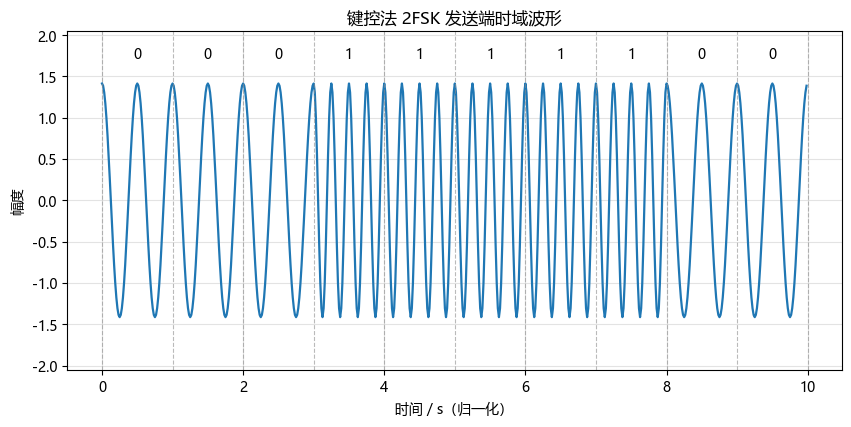

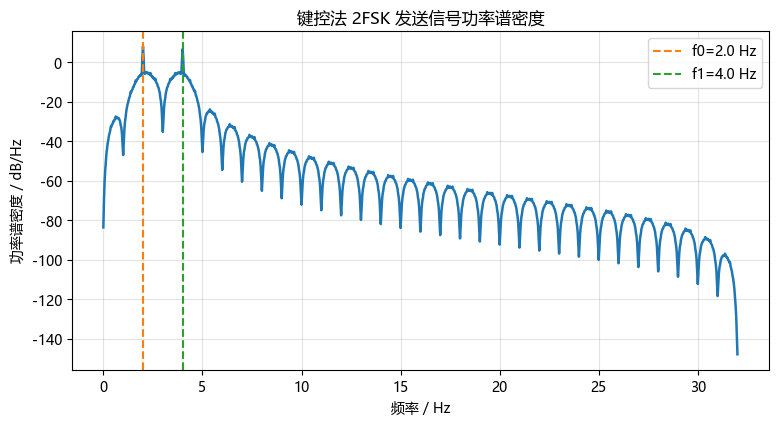

In [5]:
rng_wave = np.random.default_rng(SEED + 10)
bits_keying_wave = rng_wave.integers(0, 2, size=FSK["num_bits_wave"])
t_keying, tx_keying = fsk_keying_modulate(bits_keying_wave, FSK)

show_bits = 10
show = show_bits * FSK["sps"]
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(t_keying[:show], tx_keying[:show], lw=1.6)
for k in range(show_bits + 1):
    ax.axvline(k * FSK["Tb"], color="0.55", lw=0.8, ls="--", alpha=0.6)
for k, bit in enumerate(bits_keying_wave[:show_bits]):
    ax.text((k + 0.5) * FSK["Tb"], 1.18 * FSK["amplitude"], str(bit), ha="center", va="bottom")
ax.set_title("键控法 2FSK 发送端时域波形")
ax.set_xlabel("时间 / s（归一化）")
ax.set_ylabel("幅度")
ax.set_ylim(-1.45 * FSK["amplitude"], 1.45 * FSK["amplitude"])
plt.show()

bits_keying_psd = rng_wave.integers(0, 2, size=FSK["num_bits_psd"])
_, tx_keying_psd = fsk_keying_modulate(bits_keying_psd, FSK)
fig, ax = plt.subplots(figsize=(9, 4.4))
plot_psd(tx_keying_psd, FSK["fs"], "键控法 2FSK 发送信号功率谱密度", ax=ax)
ax.axvline(FSK["f0"], color="tab:orange", ls="--", label=f"f0={FSK['f0']:.1f} Hz")
ax.axvline(FSK["f1"], color="tab:green", ls="--", label=f"f1={FSK['f1']:.1f} Hz")
ax.legend()
plt.show()


下面观察一次具体接收过程。为了让采样点和包络变化更清楚，示例只显示前若干个码元；BER 统计会在后续代码中使用更多随机比特。


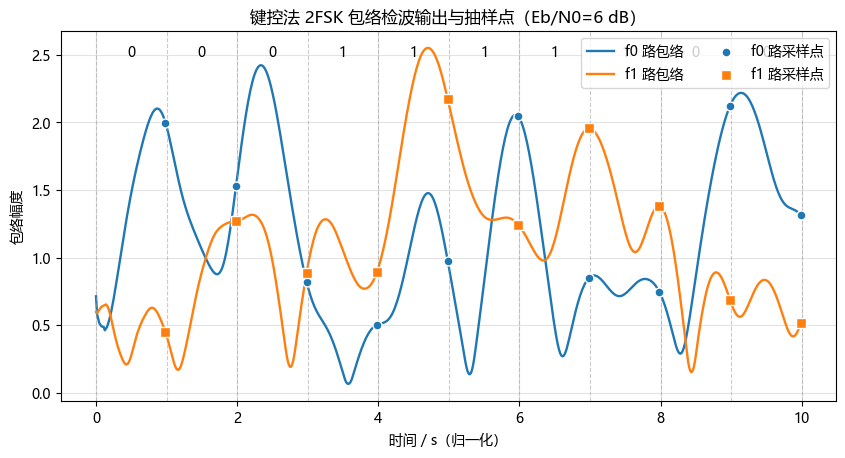

示例比特：       [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0]
示例判决：       [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0]
示例 BER=0.0500，错误数=1


In [6]:
demo_ebn0_db = 6
rng_demo = np.random.default_rng(SEED + 11)
rx_keying_demo, _ = add_awgn_passband(
    tx_keying,
    demo_ebn0_db,
    average_energy_per_symbol(tx_keying, FSK["sps"], FSK["fs"]),
    FSK["fs"],
    rng_demo,
)
bits_keying_hat, env_detail = fsk_envelope_receiver(rx_keying_demo, FSK, return_details=True)
demo_ber, demo_errors = bit_error_rate(bits_keying_wave, bits_keying_hat)

show_bits = 10
show = show_bits * FSK["sps"]
sample_idx = env_detail["sample_idx"]
mask = sample_idx < show

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(t_keying[:show], env_detail["env0_smooth"][:show], label="f0 路包络", lw=1.7)
ax.plot(t_keying[:show], env_detail["env1_smooth"][:show], label="f1 路包络", lw=1.7)
ax.scatter(
    t_keying[sample_idx[mask]],
    env_detail["env0_smooth"][sample_idx[mask]],
    marker="o",
    s=42,
    color="tab:blue",
    edgecolor="white",
    zorder=4,
    label="f0 路采样点",
)
ax.scatter(
    t_keying[sample_idx[mask]],
    env_detail["env1_smooth"][sample_idx[mask]],
    marker="s",
    s=42,
    color="tab:orange",
    edgecolor="white",
    zorder=4,
    label="f1 路采样点",
)
for k in range(show_bits + 1):
    ax.axvline(k * FSK["Tb"], color="0.6", lw=0.8, ls="--", alpha=0.5)
for k, bit in enumerate(bits_keying_wave[:show_bits]):
    ax.text((k + 0.5) * FSK["Tb"], ax.get_ylim()[1] * 0.93, str(bit), ha="center")
ax.set_title(f"键控法 2FSK 包络检波输出与抽样点（Eb/N0={demo_ebn0_db} dB）")
ax.set_xlabel("时间 / s（归一化）")
ax.set_ylabel("包络幅度")
ax.legend(ncol=2)
plt.show()

print(f"示例比特：       {bits_keying_wave.tolist()}")
print(f"示例判决：       {bits_keying_hat.tolist()}")
print(f"示例 BER={demo_ber:.4f}，错误数={demo_errors}")


对正交非相干 2FSK，常用理论误比特率为

$$
P_b=\frac{1}{2}\exp\left(-\frac{E_b/N_0}{2}\right).
$$

下面在 $E_b/N_0=-4:2:12\ \mathrm{dB}$ 范围内统计 BER，并与理论曲线比较。


键控法+包络检波 BER:   0%|          | 0/9 [00:00<?, ?it/s]

,Eb/N0 (dB),仿真 BER,错误比特数,非相干正交 2FSK 理论 BER
0,-4,0.4201,4201,0.409753
1,-2,0.3690,3690,0.364720
2,0,0.3227,3227,0.303265
3,2,0.2414,2414,0.226368
4,4,0.1559,1559,0.142404
5,6,0.0802,802,0.068311
6,8,0.0279,279,0.021324
7,10,0.0048,48,0.003369
8,12,0.0004,4,0.000181


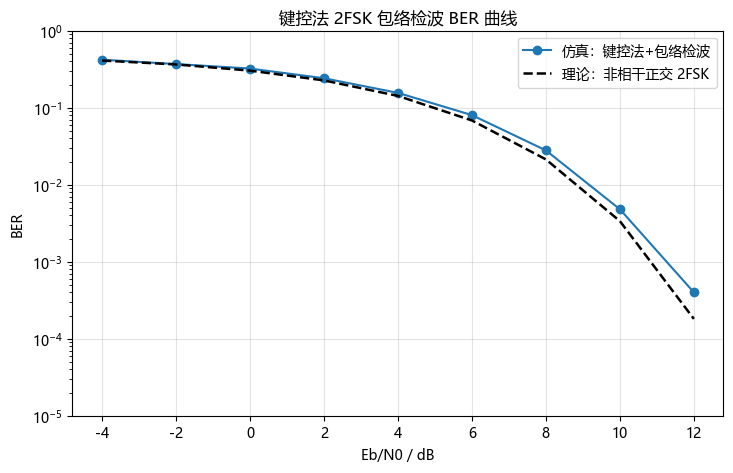

键控法发送信号估计 Eb = 1.0000


In [7]:
ber_keying, err_keying, eb_keying = simulate_fsk_envelope_ber(
    FSK["ebn0_db"], FSK["num_bits_ber"], FSK, seed=SEED + 12
)
ebn0_linear_fsk = 10 ** (FSK["ebn0_db"] / 10)
theory_noncoherent = 0.5 * np.exp(-ebn0_linear_fsk / 2)

df_keying = pd.DataFrame(
    {
        "Eb/N0 (dB)": FSK["ebn0_db"],
        "仿真 BER": ber_keying,
        "错误比特数": err_keying,
        "非相干正交 2FSK 理论 BER": theory_noncoherent,
    }
)
display(df_keying)

fig, ax = plt.subplots(figsize=(8.4, 5.0))
floor_keying = 0.5 / FSK["num_bits_ber"]
semilogy_with_floor(ax, FSK["ebn0_db"], ber_keying, "仿真：键控法+包络检波", floor_keying, marker="o")
ax.semilogy(FSK["ebn0_db"], theory_noncoherent, "k--", lw=1.8, label="理论：非相干正交 2FSK")
ax.set_title("键控法 2FSK 包络检波 BER 曲线")
ax.set_xlabel("Eb/N0 / dB")
ax.set_ylabel("BER")
ax.set_ylim(1e-5, 1)
ax.legend()
plt.show()

print(f"键控法发送信号估计 Eb = {eb_keying:.4f}")


## 4.3 方案 B：模拟调频法 + 两路相干解调

将比特映射为双极性基带信号：

$$
b_k=0\Rightarrow m(t)=-1,\qquad b_k=1\Rightarrow m(t)=+1.
$$

相位连续 2FSK 可写为

$$
s(t)=A\cos\left(2\pi f_ct+2\pi k_f\int_0^t m(\tau)\,d\tau\right),
$$

即瞬时频率为

$$
f_i(t)=f_c+k_fm(t).
$$

本实验令 $f_c=(f_0+f_1)/2$，$k_f=(f_1-f_0)/2$，因此 bit=0 时为 $f_0$，bit=1 时为 $f_1$。接收端分别与 $f_0$、$f_1$ 的本地载波相乘，并在每个码元周期内积分，比较两路相关积分值完成判决。


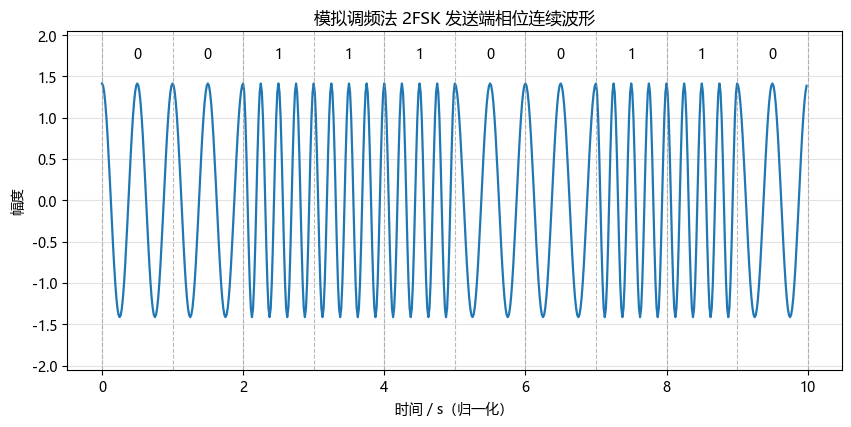

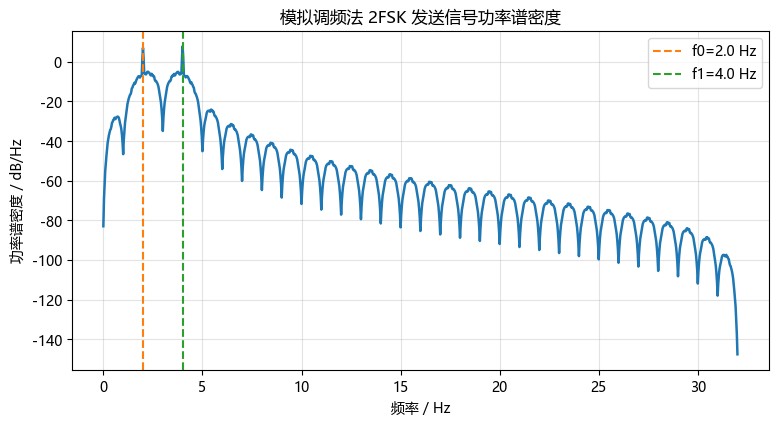

In [8]:
rng_fm = np.random.default_rng(SEED + 20)
bits_fm_wave = rng_fm.integers(0, 2, size=FSK["num_bits_wave"])
t_fm, tx_fm, f_inst = fsk_fm_modulate(bits_fm_wave, FSK)

show_bits = 10
show = show_bits * FSK["sps"]
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(t_fm[:show], tx_fm[:show], lw=1.6)
for k in range(show_bits + 1):
    ax.axvline(k * FSK["Tb"], color="0.55", lw=0.8, ls="--", alpha=0.6)
for k, bit in enumerate(bits_fm_wave[:show_bits]):
    ax.text((k + 0.5) * FSK["Tb"], 1.18 * FSK["amplitude"], str(bit), ha="center", va="bottom")
ax.set_title("模拟调频法 2FSK 发送端相位连续波形")
ax.set_xlabel("时间 / s（归一化）")
ax.set_ylabel("幅度")
ax.set_ylim(-1.45 * FSK["amplitude"], 1.45 * FSK["amplitude"])
plt.show()

bits_fm_psd = rng_fm.integers(0, 2, size=FSK["num_bits_psd"])
_, tx_fm_psd, _ = fsk_fm_modulate(bits_fm_psd, FSK)
fig, ax = plt.subplots(figsize=(9, 4.4))
plot_psd(tx_fm_psd, FSK["fs"], "模拟调频法 2FSK 发送信号功率谱密度", ax=ax)
ax.axvline(FSK["f0"], color="tab:orange", ls="--", label=f"f0={FSK['f0']:.1f} Hz")
ax.axvline(FSK["f1"], color="tab:green", ls="--", label=f"f1={FSK['f1']:.1f} Hz")
ax.legend()
plt.show()


下面观察相干解调输出。相关器在每个码元内重新积分，因此曲线在码元边界处回到新的积分起点；码元末端的抽样值用于判决。


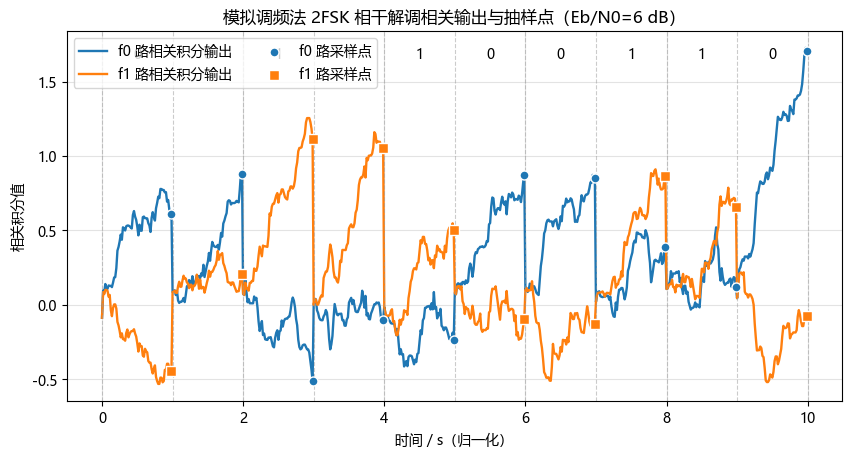

示例比特：       [0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0]
示例判决：       [0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0]
示例 BER=0.0000，错误数=0


In [9]:
demo_ebn0_db = 6
rng_demo = np.random.default_rng(SEED + 21)
rx_fm_demo, _ = add_awgn_passband(
    tx_fm,
    demo_ebn0_db,
    average_energy_per_symbol(tx_fm, FSK["sps"], FSK["fs"]),
    FSK["fs"],
    rng_demo,
)
bits_fm_hat, coh_detail = fsk_coherent_receiver(rx_fm_demo, FSK, return_details=True)
demo_ber, demo_errors = bit_error_rate(bits_fm_wave, bits_fm_hat)

show_bits = 10
show = show_bits * FSK["sps"]
sample_idx = coh_detail["sample_idx"]
mask = sample_idx < show

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(t_fm[:show], coh_detail["z0_running"][:show], label="f0 路相关积分输出", lw=1.7)
ax.plot(t_fm[:show], coh_detail["z1_running"][:show], label="f1 路相关积分输出", lw=1.7)
ax.scatter(
    t_fm[sample_idx[mask]],
    coh_detail["z0_running"][sample_idx[mask]],
    marker="o",
    s=42,
    color="tab:blue",
    edgecolor="white",
    zorder=4,
    label="f0 路采样点",
)
ax.scatter(
    t_fm[sample_idx[mask]],
    coh_detail["z1_running"][sample_idx[mask]],
    marker="s",
    s=42,
    color="tab:orange",
    edgecolor="white",
    zorder=4,
    label="f1 路采样点",
)
for k in range(show_bits + 1):
    ax.axvline(k * FSK["Tb"], color="0.6", lw=0.8, ls="--", alpha=0.5)
for k, bit in enumerate(bits_fm_wave[:show_bits]):
    ax.text((k + 0.5) * FSK["Tb"], ax.get_ylim()[1] * 0.90, str(bit), ha="center")
ax.set_title(f"模拟调频法 2FSK 相干解调相关输出与抽样点（Eb/N0={demo_ebn0_db} dB）")
ax.set_xlabel("时间 / s（归一化）")
ax.set_ylabel("相关积分值")
ax.legend(ncol=2)
plt.show()

print(f"示例比特：       {bits_fm_wave.tolist()}")
print(f"示例判决：       {bits_fm_hat.tolist()}")
print(f"示例 BER={demo_ber:.4f}，错误数={demo_errors}")


对相干正交 2FSK，理论 BER 为

$$
P_b=Q\left(\sqrt{E_b/N_0}\right),
\qquad
Q(x)=\frac{1}{2}\operatorname{erfc}\left(\frac{x}{\sqrt{2}}\right).
$$

下面统计模拟调频法 + 相干解调的 BER。


模拟调频+相干解调 BER:   0%|          | 0/9 [00:00<?, ?it/s]

,Eb/N0 (dB),仿真 BER,错误比特数,相干正交 2FSK 理论 BER
0,-4,0.2643,2643,0.264034
1,-2,0.2130,2130,0.213502
2,0,0.1523,1523,0.158655
3,2,0.1077,1077,0.104029
4,4,0.0581,581,0.056495
5,6,0.0249,249,0.023007
6,8,0.0048,48,0.006004
7,10,0.0009,9,0.000783
8,12,0.0000,0,0.000034


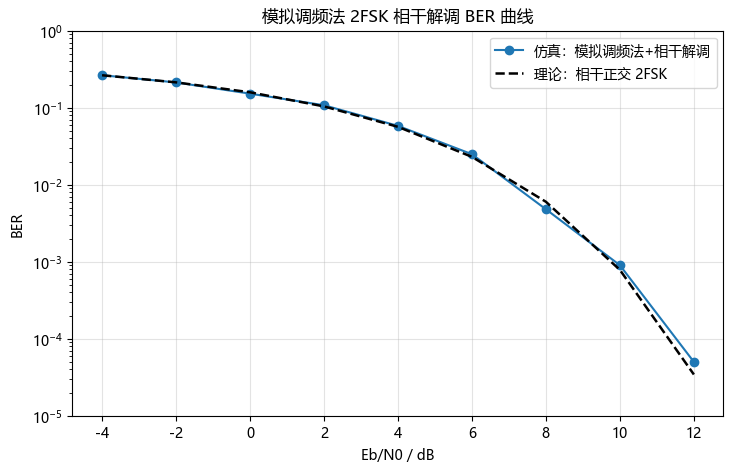

模拟调频法发送信号估计 Eb = 1.0000


In [10]:
ber_fm, err_fm, eb_fm = simulate_fsk_coherent_ber(
    FSK["ebn0_db"], FSK["num_bits_ber"], FSK, seed=SEED + 22
)
theory_coherent = Q_function(np.sqrt(ebn0_linear_fsk))

df_fm = pd.DataFrame(
    {
        "Eb/N0 (dB)": FSK["ebn0_db"],
        "仿真 BER": ber_fm,
        "错误比特数": err_fm,
        "相干正交 2FSK 理论 BER": theory_coherent,
    }
)
display(df_fm)

fig, ax = plt.subplots(figsize=(8.4, 5.0))
floor_fm = 0.5 / FSK["num_bits_ber"]
semilogy_with_floor(ax, FSK["ebn0_db"], ber_fm, "仿真：模拟调频法+相干解调", floor_fm, marker="o")
ax.semilogy(FSK["ebn0_db"], theory_coherent, "k--", lw=1.8, label="理论：相干正交 2FSK")
ax.set_title("模拟调频法 2FSK 相干解调 BER 曲线")
ax.set_xlabel("Eb/N0 / dB")
ax.set_ylabel("BER")
ax.set_ylim(1e-5, 1)
ax.legend()
plt.show()

print(f"模拟调频法发送信号估计 Eb = {eb_fm:.4f}")


## 4.4 两种 2FSK 方法 BER 曲线对比

将两种接收方式画在同一张图中。注意：包络检波属于非相干接收，通常不需要载波相位同步，但性能弱于理想相干接收；相干解调需要本地载波与发送端保持频率和相位一致，因此复杂度和同步要求更高。


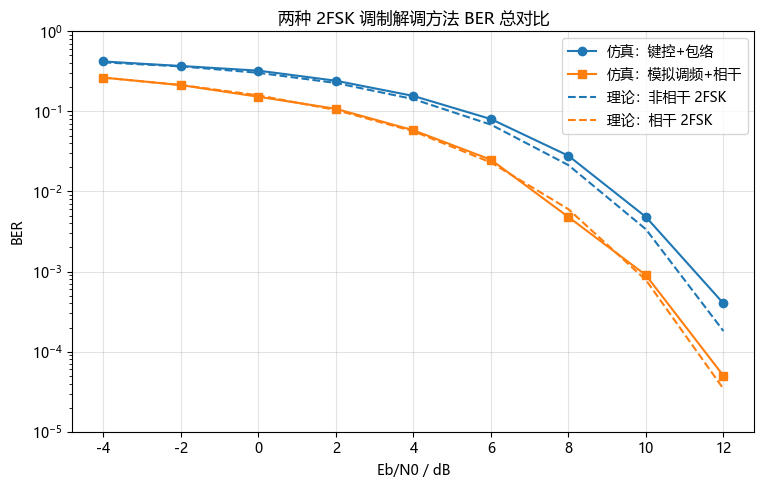

,Eb/N0 (dB),键控+包络 BER,模拟调频+相干 BER,非相干理论,相干理论
0,-4,0.4201,0.2643,0.409753,0.264034
1,-2,0.3690,0.2130,0.364720,0.213502
2,0,0.3227,0.1523,0.303265,0.158655
3,2,0.2414,0.1077,0.226368,0.104029
4,4,0.1559,0.0581,0.142404,0.056495
5,6,0.0802,0.0249,0.068311,0.023007
6,8,0.0279,0.0048,0.021324,0.006004
7,10,0.0048,0.0009,0.003369,0.000783
8,12,0.0004,0.0000,0.000181,0.000034


In [11]:
fig, ax = plt.subplots(figsize=(8.8, 5.2))
floor_fsk = 0.5 / FSK["num_bits_ber"]
semilogy_with_floor(ax, FSK["ebn0_db"], ber_keying, "仿真：键控+包络", floor_fsk, marker="o")
semilogy_with_floor(ax, FSK["ebn0_db"], ber_fm, "仿真：模拟调频+相干", floor_fsk, marker="s")
ax.semilogy(FSK["ebn0_db"], theory_noncoherent, "--", color="tab:blue", label="理论：非相干 2FSK")
ax.semilogy(FSK["ebn0_db"], theory_coherent, "--", color="tab:orange", label="理论：相干 2FSK")
ax.set_title("两种 2FSK 调制解调方法 BER 总对比")
ax.set_xlabel("Eb/N0 / dB")
ax.set_ylabel("BER")
ax.set_ylim(1e-5, 1)
ax.legend()
plt.show()

pd.DataFrame(
    {
        "Eb/N0 (dB)": FSK["ebn0_db"],
        "键控+包络 BER": ber_keying,
        "模拟调频+相干 BER": ber_fm,
        "非相干理论": theory_noncoherent,
        "相干理论": theory_coherent,
    }
)


## 4.5 2FSK 结果分析

1. **时域波形**：键控法在每个码元中直接选择 $f_0$ 或 $f_1$，波形频率随比特变化；模拟调频法通过积分生成相位，波形相位连续，更接近实际调频器输出。
2. **功率谱密度**：两种 2FSK 的主要能量集中在 $f_0$ 和 $f_1$ 附近。由于随机码元切换会造成频谱展宽，因此谱线不是理想冲激。
3. **包络检波**：两路滤波器分别提取两种频率成分，发送哪个频率，哪一路包络能量通常更大。该方法不依赖载波相位，因此属于非相干检测，但抗噪声能力弱于相干检测。
4. **相干解调**：相关积分利用了已知载波相位和频率，能够充分利用信号的相干信息，所以 BER 理论上低于非相干包络检波。
5. **仿真与理论差异**：有限比特数会造成高信噪比处的 BER 抖动甚至出现 0 错误；带通滤波器、Hilbert 包络、采样点选择和边界瞬态也会让包络检波曲线与理想非相干理论存在偏差。


# 5. 第二部分：IQ 调制仿真

## 5.1 IQ 调制基本原理

IQ 调制把二维星座点 $I+jQ$ 搬移到通带。若 $I$、$Q$ 在一个符号周期内保持不变，则通带信号可写为

$$
s(t)=\sqrt{\frac{2}{T_s}}\left[I\cos(2\pi f_ct)-Q\sin(2\pi f_ct)\right],
\quad 0\le t<T_s.
$$

其中 $\cos(2\pi f_ct)$ 与 $-\sin(2\pi f_ct)$ 是两路正交载波。接收端相干解调时分别与这两个正交基函数相乘并积分：

$$
\hat I=\int_0^{T_s}r(t)\sqrt{\frac{2}{T_s}}\cos(2\pi f_ct)\,dt,
$$

$$
\hat Q=\int_0^{T_s}r(t)\left[-\sqrt{\frac{2}{T_s}}\sin(2\pi f_ct)\right]\,dt.
$$

在 AWGN 且各星座点等概条件下，MAP 判决等价于 ML 判决，即选择与接收点欧氏距离最近的星座点。


## 5.2 16QAM 星座设计与 Gray 映射

本实验选择 $M=16$ 的 16QAM，满足 $M\ge 8$。未归一化星座取

$$
I,Q\in\{-3,-1,+1,+3\}.
$$

该星座平均符号能量为

$$
E_s=\mathbb{E}[I^2+Q^2]=10,
$$

因此除以 $\sqrt{10}$ 后得到 $E_s=1$ 的归一化星座。每个轴使用 2 bit Gray 映射：

$$
00\to -3,\quad 01\to -1,\quad 11\to +1,\quad 10\to +3.
$$


,bits,I 未归一化,Q 未归一化,I 归一化,Q 归一化
0,0000,-3,-3,-0.948683,-0.948683
1,0001,-3,-1,-0.948683,-0.316228
2,0011,-3,1,-0.948683,0.316228
3,0010,-3,3,-0.948683,0.948683
4,0100,-1,-3,-0.316228,-0.948683
5,0101,-1,-1,-0.316228,-0.316228
6,0111,-1,1,-0.316228,0.316228
7,0110,-1,3,-0.316228,0.948683
8,1100,1,-3,0.316228,-0.948683
9,1101,1,-1,0.316228,-0.316228


M = 16, 每符号比特数 = 4
归一化后平均符号能量 Es = 1.0000


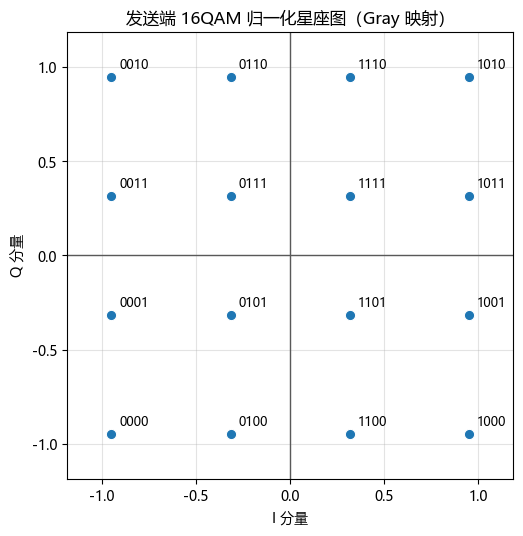

In [12]:
def make_16qam_gray_constellation():
    gray_axis = [
        ((0, 0), -3),
        ((0, 1), -1),
        ((1, 1), +1),
        ((1, 0), +3),
    ]
    norm = np.sqrt(10)
    mapping = {}
    rows = []
    for i_bits, i_level in gray_axis:
        for q_bits, q_level in gray_axis:
            bits = tuple(i_bits + q_bits)
            symbol = (i_level + 1j * q_level) / norm
            mapping[bits] = symbol
            rows.append(
                {
                    "bits": "".join(str(b) for b in bits),
                    "I 未归一化": i_level,
                    "Q 未归一化": q_level,
                    "I 归一化": symbol.real,
                    "Q 归一化": symbol.imag,
                }
            )
    bit_tuples = list(mapping.keys())
    constellation = np.array([mapping[b] for b in bit_tuples])
    labels = ["".join(str(v) for v in b) for b in bit_tuples]
    df = pd.DataFrame(rows)
    return mapping, bit_tuples, constellation, labels, df


qam_mapping, qam_bit_tuples, qam_constellation, qam_labels, qam_df = make_16qam_gray_constellation()
display(qam_df)
print(f"M = {IQ['M']}, 每符号比特数 = {IQ['bits_per_symbol']}")
print(f"归一化后平均符号能量 Es = {np.mean(np.abs(qam_constellation) ** 2):.4f}")

fig, ax = plt.subplots(figsize=(5.8, 5.8))
plot_constellation(qam_constellation, qam_labels, title="发送端 16QAM 归一化星座图（Gray 映射）", ax=ax)
plt.show()


下面实现“比特 $\rightarrow$ 星座点”的映射、IQ 通带调制、相干解调和最近邻 ML 判决函数。


In [13]:
def bits_to_16qam_symbols(bits, mapping):
    bits = np.asarray(bits).astype(int)
    k = 4
    n_symbols = bits.size // k
    bits = bits[: n_symbols * k].reshape(n_symbols, k)
    symbols = np.array([mapping[tuple(row)] for row in bits])
    return symbols, bits.reshape(-1)


def iq_modulate(symbols, params):
    symbols = np.asarray(symbols)
    sps, fs, ts, fc = params["sps"], params["fs"], params["Ts"], params["fc"]
    amp = params["carrier_amp"]
    n_symbols = symbols.size
    t = np.arange(n_symbols * sps) / fs
    i_up = np.repeat(symbols.real, sps)
    q_up = np.repeat(symbols.imag, sps)
    tx = amp * (i_up * np.cos(2 * np.pi * fc * t) - q_up * np.sin(2 * np.pi * fc * t))
    return t, tx, i_up, q_up


def iq_coherent_demod(rx, params):
    sps, fs, ts, fc = params["sps"], params["fs"], params["Ts"], params["fc"]
    amp = params["carrier_amp"]
    n_symbols = len(rx) // sps
    rx = np.asarray(rx[: n_symbols * sps])
    t = np.arange(n_symbols * sps) / fs
    i_basis = amp * np.cos(2 * np.pi * fc * t)
    q_basis = -amp * np.sin(2 * np.pi * fc * t)
    i_hat = np.sum((rx * i_basis).reshape(n_symbols, sps), axis=1) / fs
    q_hat = np.sum((rx * q_basis).reshape(n_symbols, sps), axis=1) / fs
    return i_hat + 1j * q_hat


def nearest_neighbor_detect(rx_symbols, constellation, bit_tuples):
    rx_symbols = np.asarray(rx_symbols)
    distances = np.abs(rx_symbols[:, None] - constellation[None, :]) ** 2
    idx = np.argmin(distances, axis=1)
    detected_symbols = constellation[idx]
    bit_array = np.array(bit_tuples, dtype=int)
    detected_bits = bit_array[idx].reshape(-1)
    return detected_bits, detected_symbols, idx


def simulate_16qam_ber_passband(ebn0_db_values, num_bits, params, mapping, constellation, bit_tuples, seed):
    rng = np.random.default_rng(seed)
    k = params["bits_per_symbol"]
    num_bits = (num_bits // k) * k
    bits = rng.integers(0, 2, size=num_bits)
    symbols, bits_used = bits_to_16qam_symbols(bits, mapping)
    _, tx, _, _ = iq_modulate(symbols, params)

    # 16QAM 星座已经归一化到 Es=1，因此 Eb=Es/k=1/k。
    eb = 1 / k
    ber, errors = [], []
    for ebn0_db in tqdm(ebn0_db_values, desc="16QAM IQ BER"):
        rx, _ = add_awgn_passband(tx, ebn0_db, eb, params["fs"], rng)
        rx_symbols = iq_coherent_demod(rx, params)
        bits_hat, _, _ = nearest_neighbor_detect(rx_symbols, constellation, bit_tuples)
        this_ber, this_errors = bit_error_rate(bits_used, bits_hat)
        ber.append(this_ber)
        errors.append(this_errors)
    return np.array(ber), np.array(errors)


## 5.3 发送端 IQ 调制

先展示几个典型星座点在一个符号周期内对应的通带波形。可以看到，不同 $I,Q$ 组合会改变载波的幅度和相位。


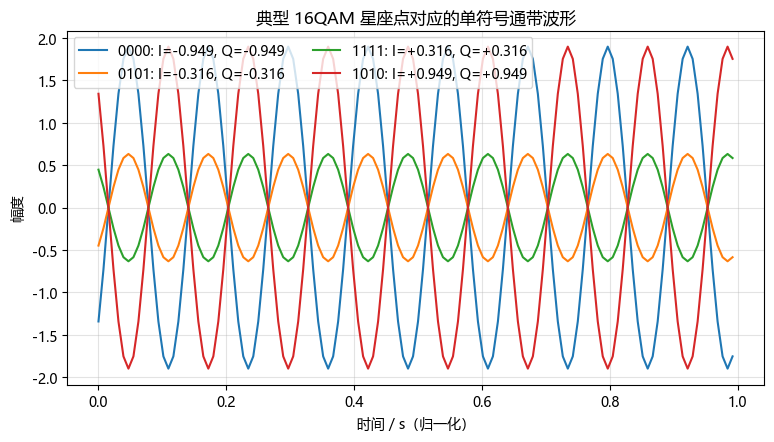

In [14]:
label_to_symbol = {"".join(str(b) for b in bits): sym for bits, sym in qam_mapping.items()}
typical_labels = ["0000", "0101", "1111", "1010"]

fig, ax = plt.subplots(figsize=(9, 4.6))
for label in typical_labels:
    symbol = label_to_symbol[label]
    t_one, s_one, _, _ = iq_modulate(np.array([symbol]), IQ)
    ax.plot(
        t_one,
        s_one,
        lw=1.5,
        label=f"{label}: I={symbol.real:+.3f}, Q={symbol.imag:+.3f}",
    )
ax.set_title("典型 16QAM 星座点对应的单符号通带波形")
ax.set_xlabel("时间 / s（归一化）")
ax.set_ylabel("幅度")
ax.legend(ncol=2)
plt.show()


接着随机产生若干个 16QAM 符号，画出基带 $I(t)$、$Q(t)$ 和通带信号 $s(t)$。


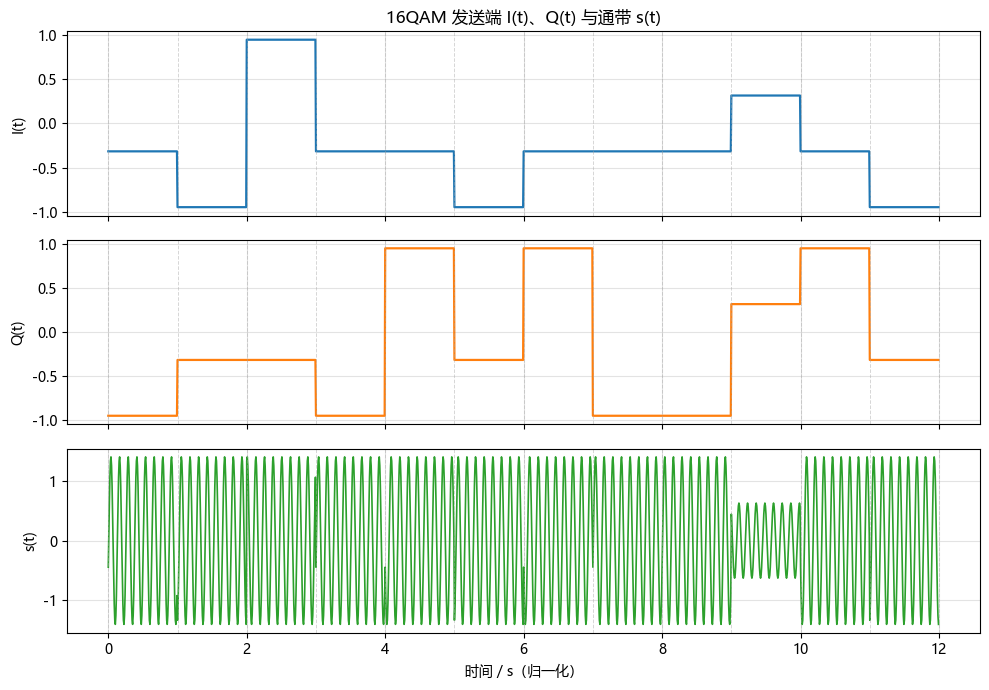

发送比特： [0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1]
发送符号： [-0.316-0.949j -0.949-0.316j  0.949-0.316j -0.316-0.949j -0.316+0.949j
 -0.949-0.316j -0.316+0.949j -0.316-0.949j -0.316-0.949j  0.316+0.316j
 -0.316+0.949j -0.949-0.316j]


In [15]:
rng_iq_wave = np.random.default_rng(SEED + 30)
bits_iq_wave = rng_iq_wave.integers(0, 2, size=IQ["num_symbols_wave"] * IQ["bits_per_symbol"])
symbols_iq_wave, bits_iq_wave_used = bits_to_16qam_symbols(bits_iq_wave, qam_mapping)
t_iq, tx_iq, i_up, q_up = iq_modulate(symbols_iq_wave, IQ)

fig, axes = plt.subplots(3, 1, figsize=(10, 7.0), sharex=True)
axes[0].plot(t_iq, i_up, color="tab:blue", lw=1.6)
axes[0].set_ylabel("I(t)")
axes[0].set_title("16QAM 发送端 I(t)、Q(t) 与通带 s(t)")

axes[1].plot(t_iq, q_up, color="tab:orange", lw=1.6)
axes[1].set_ylabel("Q(t)")

axes[2].plot(t_iq, tx_iq, color="tab:green", lw=1.2)
axes[2].set_ylabel("s(t)")
axes[2].set_xlabel("时间 / s（归一化）")

for ax in axes:
    for k in range(IQ["num_symbols_wave"] + 1):
        ax.axvline(k * IQ["Ts"], color="0.65", lw=0.7, ls="--", alpha=0.45)
plt.tight_layout()
plt.show()

print("发送比特：", bits_iq_wave_used.tolist())
print("发送符号：", np.round(symbols_iq_wave, 3))


## 5.4 AWGN 信道与 5.5 接收端相干解调

通带信号经过 AWGN 后，接收端分别与 $\cos(2\pi f_ct)$ 和 $-\sin(2\pi f_ct)$ 相乘并积分，恢复接收星座点。下面画出 $E_b/N_0=0,6,12\ \mathrm{dB}$ 时的接收星座图。


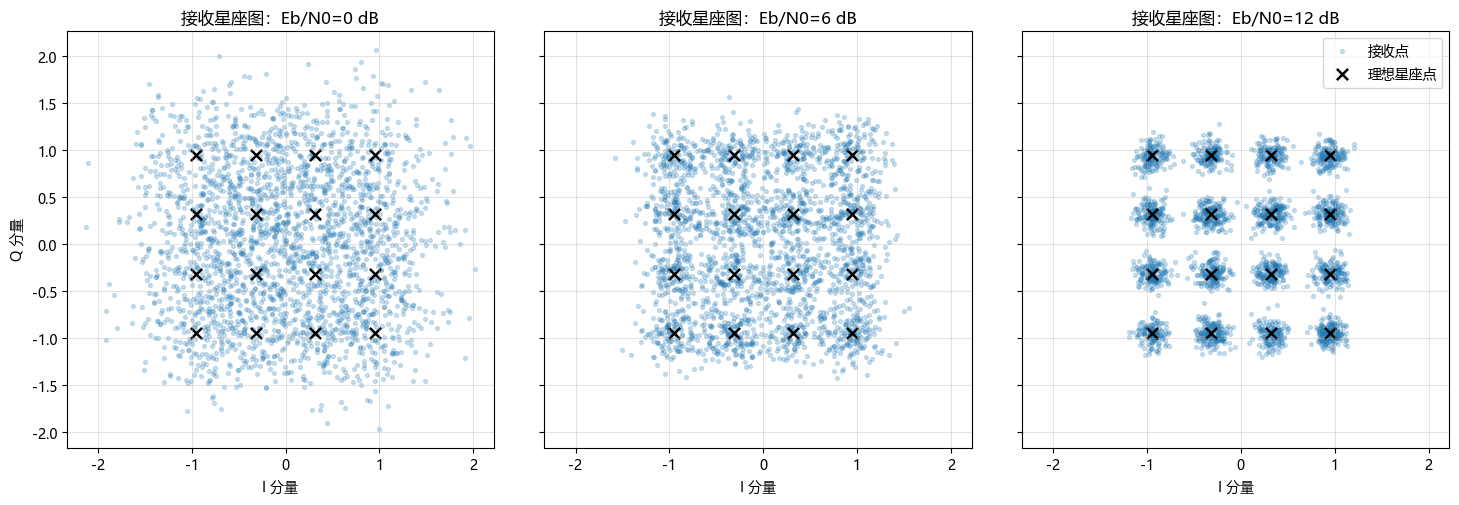

In [16]:
rng_scatter = np.random.default_rng(SEED + 31)
scatter_bits = rng_scatter.integers(
    0,
    2,
    size=IQ["num_symbols_scatter"] * IQ["bits_per_symbol"],
)
scatter_symbols, scatter_bits_used = bits_to_16qam_symbols(scatter_bits, qam_mapping)
_, tx_scatter, _, _ = iq_modulate(scatter_symbols, IQ)
eb_qam = 1 / IQ["bits_per_symbol"]

fig, axes = plt.subplots(1, len(IQ["scatter_ebn0_db"]), figsize=(15, 4.8), sharex=True, sharey=True)
for ax, ebn0_db in zip(axes, IQ["scatter_ebn0_db"]):
    rx_scatter, _ = add_awgn_passband(tx_scatter, ebn0_db, eb_qam, IQ["fs"], rng_scatter)
    rx_symbols = iq_coherent_demod(rx_scatter, IQ)
    ax.scatter(rx_symbols.real, rx_symbols.imag, s=8, alpha=0.22, label="接收点")
    ax.scatter(
        qam_constellation.real,
        qam_constellation.imag,
        s=65,
        color="black",
        marker="x",
        linewidth=1.8,
        label="理想星座点",
    )
    ax.set_title(f"接收星座图：Eb/N0={ebn0_db} dB")
    ax.set_xlabel("I 分量")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.35)
axes[0].set_ylabel("Q 分量")
axes[-1].legend(loc="upper right")
plt.tight_layout()
plt.show()


## 5.6 MAP/ML 判决

在等先验、AWGN 条件下，

$$
\hat{s}
=\arg\max_{s_m}p(r|s_m)
=\arg\min_{s_m}|r-s_m|^2.
$$

因而 ML/MAP 判决的几何意义就是：在星座图上找到距离接收点最近的理想星座点。下面对一个信噪比示例执行最近邻判决并统计 BER。


Eb/N0=8 dB 时，最近邻 ML/MAP 判决 BER=0.00880，错误比特数=88


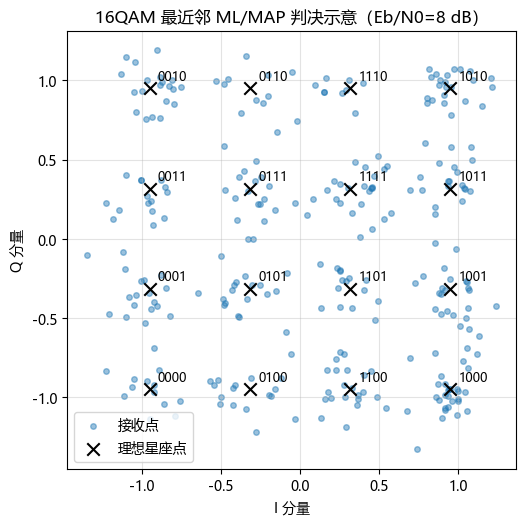

In [17]:
demo_ebn0_db = 8
rng_ml_demo = np.random.default_rng(SEED + 32)
rx_demo, _ = add_awgn_passband(tx_scatter, demo_ebn0_db, eb_qam, IQ["fs"], rng_ml_demo)
rx_symbols_demo = iq_coherent_demod(rx_demo, IQ)
bits_demo_hat, symbols_demo_hat, nearest_idx = nearest_neighbor_detect(
    rx_symbols_demo, qam_constellation, qam_bit_tuples
)
ber_demo_qam, err_demo_qam = bit_error_rate(scatter_bits_used, bits_demo_hat)

print(f"Eb/N0={demo_ebn0_db} dB 时，最近邻 ML/MAP 判决 BER={ber_demo_qam:.5f}，错误比特数={err_demo_qam}")

fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.scatter(rx_symbols_demo.real[:300], rx_symbols_demo.imag[:300], s=16, alpha=0.45, label="接收点")
ax.scatter(qam_constellation.real, qam_constellation.imag, s=80, color="black", marker="x", label="理想星座点")
for point, label in zip(qam_constellation, qam_labels):
    ax.annotate(label, (point.real, point.imag), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_title(f"16QAM 最近邻 ML/MAP 判决示意（Eb/N0={demo_ebn0_db} dB）")
ax.set_xlabel("I 分量")
ax.set_ylabel("Q 分量")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()


## 5.7 BER 曲线与理论曲线对比

对方形 $M$-QAM，Gray 映射下常用近似 BER 为

$$
P_b\approx
\frac{4}{\log_2 M}\left(1-\frac{1}{\sqrt{M}}\right)
Q\left(
\sqrt{
\frac{3\log_2M}{M-1}\frac{E_b}{N_0}
}
\right).
$$

下面在 $E_b/N_0=0:2:20\ \mathrm{dB}$ 范围内进行仿真。高信噪比处可能出现 0 错误，绘图时用 $0.5/N_\mathrm{bits}$ 作为显示下限，表格中仍保留真实统计值。


16QAM IQ BER:   0%|          | 0/11 [00:00<?, ?it/s]

,Eb/N0 (dB),仿真 BER,错误比特数,16QAM 近似理论 BER
0,0,0.139775,5591,1.391600e-01
1,2,0.096350,3854,9.755935e-02
2,4,0.058650,2346,5.861846e-02
3,6,0.027925,1117,2.787131e-02
4,8,0.009500,380,9.247214e-03
5,10,0.001900,76,1.754151e-03
6,12,0.000175,7,1.386587e-04
7,14,0.000000,0,2.763208e-06
8,16,0.000000,0,6.250201e-09
9,18,0.000000,0,4.522309e-13


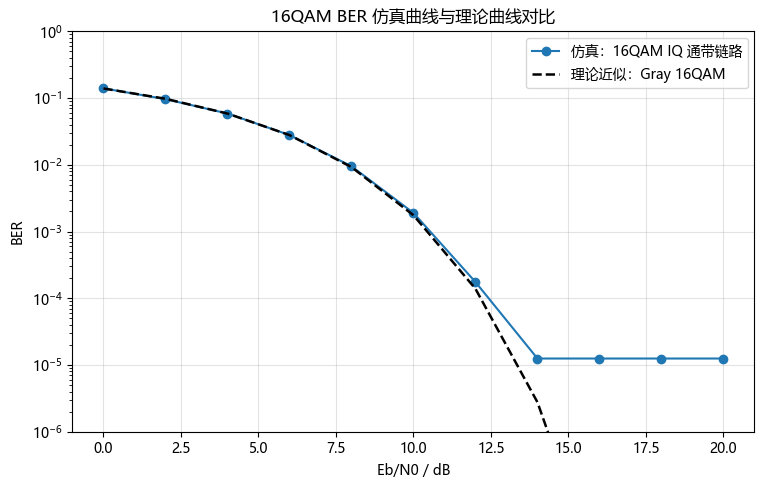

In [18]:
ber_qam, err_qam = simulate_16qam_ber_passband(
    IQ["ebn0_db"],
    IQ["num_bits_ber"],
    IQ,
    qam_mapping,
    qam_constellation,
    qam_bit_tuples,
    seed=SEED + 33,
)

ebn0_linear_qam = 10 ** (IQ["ebn0_db"] / 10)
M = IQ["M"]
k = IQ["bits_per_symbol"]
theory_16qam = (4 / k) * (1 - 1 / np.sqrt(M)) * Q_function(
    np.sqrt(3 * k / (M - 1) * ebn0_linear_qam)
)

df_qam = pd.DataFrame(
    {
        "Eb/N0 (dB)": IQ["ebn0_db"],
        "仿真 BER": ber_qam,
        "错误比特数": err_qam,
        "16QAM 近似理论 BER": theory_16qam,
    }
)
display(df_qam)

fig, ax = plt.subplots(figsize=(8.8, 5.2))
floor_qam = 0.5 / IQ["num_bits_ber"]
semilogy_with_floor(ax, IQ["ebn0_db"], ber_qam, "仿真：16QAM IQ 通带链路", floor_qam, marker="o")
ax.semilogy(IQ["ebn0_db"], theory_16qam, "k--", lw=1.8, label="理论近似：Gray 16QAM")
ax.set_title("16QAM BER 仿真曲线与理论曲线对比")
ax.set_xlabel("Eb/N0 / dB")
ax.set_ylabel("BER")
ax.set_ylim(1e-6, 1)
ax.legend()
plt.show()


## 5.8 IQ 调制结果分析

1. **星座归一化**：16QAM 的 $I,Q$ 取值为 $\{-3,-1,+1,+3\}$，除以 $\sqrt{10}$ 后平均符号能量 $E_s=1$。由于每个符号携带 4 bit，所以 $E_b=E_s/4$。
2. **接收星座图**：当 $E_b/N_0$ 较低时，接收点云分散，容易越过判决边界；随着 $E_b/N_0$ 增大，点云向理想星座点收缩，误判概率降低。
3. **ML/MAP 判决**：在等先验 AWGN 信道中，后验概率最大等价于欧氏距离最小，因此最近邻判决就是 ML/MAP 判决。
4. **高阶调制抗噪声能力**：16QAM 每个符号携带更多 bit，但星座点之间距离比低阶调制更近，同样噪声下更容易判错。
5. **仿真与理论差异**：理论公式是近似结果；有限比特数会带来统计波动，高信噪比处可能没有观测到错误；此外，通带采样、积分近似和有限符号长度也会造成细小偏差。


# 6. 总结

本 Notebook 完成了 2FSK 和 16QAM IQ 两类调制系统的完整链路仿真。

- **2FSK 键控法 + 包络检波**：结构直观，不需要载波相位同步，适合说明非相干检测思想；BER 随 $E_b/N_0$ 增大而下降，整体趋势符合非相干正交 2FSK 理论。
- **2FSK 模拟调频法 + 相干解调**：通过相位积分得到连续相位信号，接收端使用相关积分判决；由于利用了相干信息，理论性能优于包络检波。
- **16QAM IQ 调制**：完成了 Gray 映射、通带 IQ 调制、AWGN 信道、相干解调和最近邻 ML/MAP 判决；接收星座图和 BER 曲线体现了 $E_b/N_0$ 增大时误码率下降的规律。

总体看，仿真结果与理论预期一致：信噪比越高，接收点越集中、BER 越低；相干检测通常优于非相干检测；高阶 IQ 调制提高频谱效率的同时也牺牲了一定抗噪声能力。
